In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate

# Explore csv

In [2]:
DATASET = f'paysim10K-modified.csv'

df = pd.read_csv(DATASET)
# df = df.iloc[:500000]
df

,step,action,amount,nameOrig,oldBalanceOrig,newBalanceOrig,nameDest,oldBalanceDest,newBalanceDest,isFraud,isFlaggedFraud,isUnauthorizedOverdraft
0,0,TRANSFER,49.56,C0299701932,49.56,0.00,CC0878772992,0.00,49.56,1,0,0
1,0,CASH_OUT,49.56,CC0878772992,49.56,0.00,M5014725181,0.00,49.56,1,0,0
2,0,TRANSFER,82.17,C7928724461,82.17,0.00,CC8089905936,0.00,82.17,1,0,0
3,0,CASH_OUT,82.17,CC8089905936,82.17,0.00,M6331656262,0.00,82.17,1,0,0
4,0,TRANSFER,70.32,C8812588870,70.32,0.00,CC6100430678,0.00,70.32,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1100721,364,TRANSFER,5705490.97,C1840727463,5705490.97,0.00,CC3756097793,0.00,5705490.97,1,0,0
1100722,364,CASH_OUT,5705490.97,CC3756097793,5705490.97,0.00,M0749872103,-11072422.20,-5366931.23,1,0,0
1100723,364,TRANSFER,3576095.52,C9144680491,3576095.52,0.00,CC5897210972,0.00,3576095.52,1,0,0
1100724,364,CASH_OUT,3576095.52,CC5897210972,3576095.52,0.00,M3705964922,-14186903.99,-10610808.47,1,0,0


In [3]:
prefixes1 = df['nameOrig'].str[0].unique()
prefixes2 = df['nameDest'].str[0].unique()

print(prefixes1, prefixes2)

df['action'].unique()

['C'] ['C' 'M' 'B']


array(['TRANSFER', 'CASH_OUT', 'CASH_IN', 'PAYMENT', 'DEBIT'],
      dtype=object)

In [4]:
df['isFraud'].unique()

array([1, 0])

In [5]:
balances = {}
fraud = 0

for _, row in df.iterrows():
    is_fraud = row['isFraud']
    orig = row['nameOrig']
    dest = row['nameDest']
    oldorig = row['oldBalanceOrig']
    olddest = row['oldBalanceDest']
    neworig = row['newBalanceOrig']
    newdest = row['newBalanceDest']

    # Track origin account
    if row['nameOrig'] not in balances:
        balances[row['nameOrig']] = {}
    balances[row['nameOrig']][row['step']] = row['newBalanceOrig']

    # if orig == 'M7146327871':
    #     print(f"step : {row['step']}")
    #     print(f"amount: {row['amount']}")
    #     print(f"old orig: {oldorig}")
    #     print(f"new orig: {neworig}")
    # if dest == 'M7146327871':
    #     print(f"step : {row['step']}")
    #     print(f"amount: {row['amount']}")
    #     print(f"old dest: {olddest}")
    #     print(f"new dest: {newdest}")

    # Track destination account
    if row['nameDest'] not in balances:
        balances[row['nameDest']] = {}
    balances[row['nameDest']][row['step']] = row['newBalanceDest']

    if is_fraud:
        fraud += 1

In [6]:
print(f"Total fraudolent transactions: {fraud} out of {len(df)} transactions")
fraud_perc = fraud / len(df)
print(f"Anomaly percentage: {round(fraud_perc * 100, 2)}")

Total fraudolent transactions: 1444 out of 1100726 transactions
Anomaly percentage: 0.13


In [7]:
print(f"Number of users: {len(balances)}")

Number of users: 10284


In [8]:
# Create DataFrame
balance_df = pd.DataFrame.from_dict(balances, orient='index').T

# Identify the full range of steps (days)
full_range = range(balance_df.index.min(), balance_df.index.max() + 1)

# Reindex to include all steps, then forward fill
balance_df = balance_df.reindex(full_range).fillna(method='ffill').fillna(method='bfill')

/var/folders/s6/4jprwbqj4012tkll2ww6r5hr0000gq/T/ipykernel_3054/707783276.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  balance_df = balance_df.reindex(full_range).fillna(method='ffill').fillna(method='bfill')


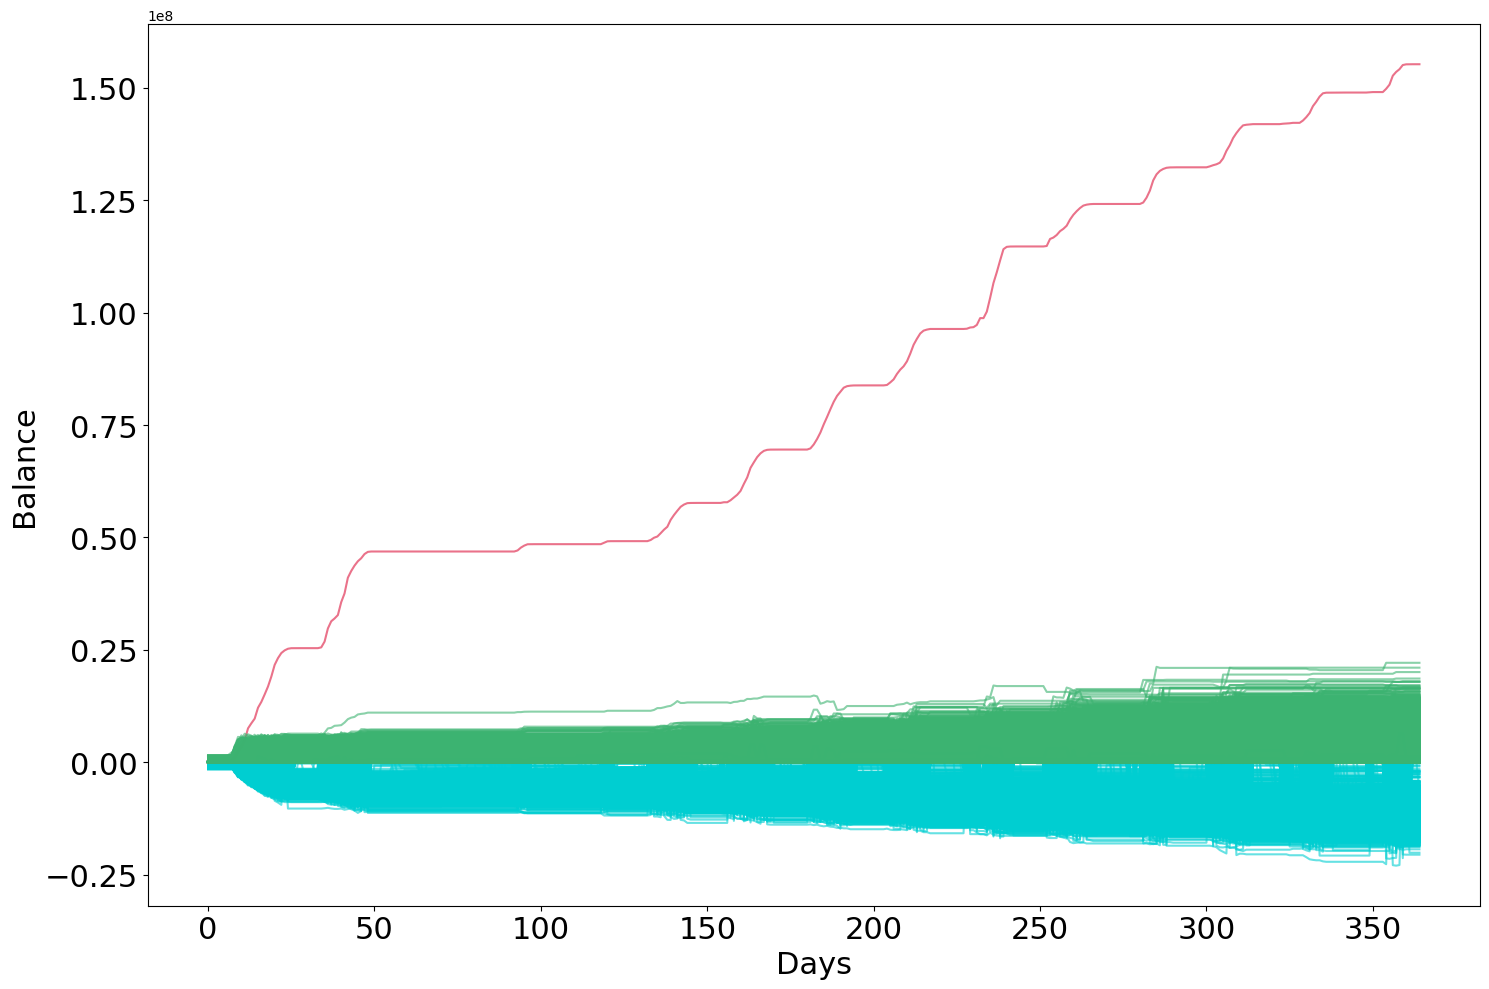

In [9]:
# Plot the balance evolution for all users (columns) as separate lines
# plt.figure(figsize=(15,10), dpi= 300)
plt.figure(figsize=(15,10))

# Plot each column (account balance) as a line
for user in balance_df.columns:
    if user.startswith('C'):
        color = 'mediumseagreen'
    elif user.startswith('B'):
        color = 'crimson'
    else:
        color = 'darkturquoise'
    plt.plot(balance_df.index, balance_df[user], color=color, label=f"User {user}", alpha=0.6)

# Add title and labels
plt.xlabel("Days", fontsize=22)
plt.ylabel("Balance", fontsize=22)

# Rotate x-axis labels for better visibility
plt.tick_params(axis='x', labelsize=22)
plt.tick_params(axis='y', labelsize=22)

# Display the plot
plt.tight_layout()
plt.show()

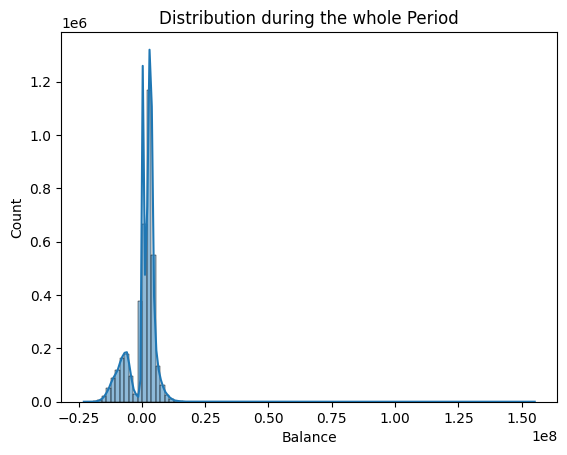

In [10]:
values_df = balance_df.values.flatten()
# Plot distribution for all the days (aggregated over users and days)
sns.histplot(values_df, bins=100, kde=True)
plt.title("Distribution during the whole Period")
plt.xlabel("Balance")
plt.show()

In [11]:
balance_df.T

,0,1,2,3,4,5,6,7,8,9,...,355,356,357,358,359,360,361,362,363,364
C0299701932,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,304631.59,304631.59,...,3387894.87,3387894.87,3387894.87,3387894.87,3387894.87,3387894.87,3387894.87,3387894.87,3387894.87,3387894.87
CC0878772992,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,3245332.06,3245332.06,3245332.06,3245332.06,3245332.06,3842170.35,3842170.35,3842170.35,3842170.35,3842170.35
M5014725181,49.56,49.56,49.56,49.56,49.56,49.56,49.56,-214667.47,-417800.58,-853118.65,...,-9716510.41,-9712207.42,582752.38,-9778503.68,-9778503.68,592077.94,592077.94,592077.94,592077.94,592077.94
C7928724461,0.00,0.00,0.00,0.00,0.00,0.00,0.00,182663.75,985983.14,1427293.69,...,3990527.44,4488841.16,4402831.70,4381622.47,4176468.07,3859138.43,3859138.43,3859138.43,3859138.43,3859138.43
CC8089905936,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,10332650.97,10332650.97,10332650.97,10332650.97,10332650.97,10332650.97,10332650.97,10332650.97,10332650.97,10332650.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CC1944838858,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
CC9271132759,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
CC8709253092,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
CC2595824747,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


# SQUIC

In [12]:
df = balance_df

In [13]:
ROWS = len(df.iloc[0])
ROWS

10284

## Normalization

In [14]:
Y = df.T.to_numpy()  # Transpose to get shape (users, days)
#l = [1e5, 3e5, 5e5, 7e5, 9e5, 11e5, 13e5, 15e5, 17e5, 19e5]

l = [9e-1, 5e-1, 2e-1, 1e-1, 9e-2, 5e-2, 2e-2, 1e-2]

In [15]:
print(np.isnan(Y).sum())  # should be 0 (no NaN)
print(np.linalg.matrix_rank(Y))  # should be full rank (ideally)
print(np.linalg.cond(Y))  # condition number; high = bad

0
357
1.4612836784970918e+19


In [16]:
from SQUIC_functions import *

In [17]:
squic_dict = {}

In [18]:
Y = df.T.to_numpy()
# normalize the Y input data to achieve unit variance
Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# normalizes each row so that the std dev of each user's balance over the days becomes 1

# Y_new has shape (Users × Days).
# S will have shape (Users × Users).

# double check if this is correct by 
S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

/var/folders/s6/4jprwbqj4012tkll2ww6r5hr0000gq/T/ipykernel_3054/3409128255.py:3: RuntimeWarning: divide by zero encountered in divide
  Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation


In [19]:
print("NaNs?", np.isnan(Y_new).any())
print("Infs?", np.isinf(Y_new).any())
print("Max:", np.max(Y_new))
print("Min:", np.min(Y_new))
print("Mean std per row (should be 1):", round(np.mean(np.std(Y_new, axis=1)), 2))

NaNs? True
Infs? False
Max: nan
Min: nan
Mean std per row (should be 1): nan


In [20]:
stds = np.std(Y, axis=1)
safe_stds = np.clip(stds, 1e-8, None)  # don't allow std < 1e-8
Y_new = np.diag(1 / safe_stds) @ Y

print("NaNs?", np.isnan(Y_new).any())
print("Infs?", np.isinf(Y_new).any())
print("Max:", np.max(Y_new))
print("Min:", np.min(Y_new))
print("Mean std per row (should be 1):", round(np.mean(np.std(Y_new, axis=1)), 2))

NaNs? False
Infs? False
Max: 134667574000000.0
Min: -4.515247915473027
Mean std per row (should be 1): 0.99


In [21]:
print(np.linalg.cond(Y_new))  # condition number; high = bad

1.0609369803093699e+30


In [22]:
# l = [0.9, 0.5, 0.2, 0.1, 0.09, 0.05, 0.02, 0.01]
l = [0.99, 0.97, 0.95]

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           10284 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.900000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=1.18e-01 nnz(S)/p=1.25e+00
* iter=1 time=1.75e-02 obj=1.73e+04 |delta(obj)|/obj=4.10e-01 nnz(X,L,W)/p=[1.25e+00 9.78e-01 1.00e+00] lns_iter=2 
* iter=2 time=2.25e-02 obj=1.73e+04 |delta(obj)|/obj=5.99e-06 nnz(X,L,W)/p=[1.25e+00 9.78e-01 1.10e+00] lns_iter=1 
#SQUIC Finished: time=1.60e-01 nnz(X,W)/p=[1.25e+

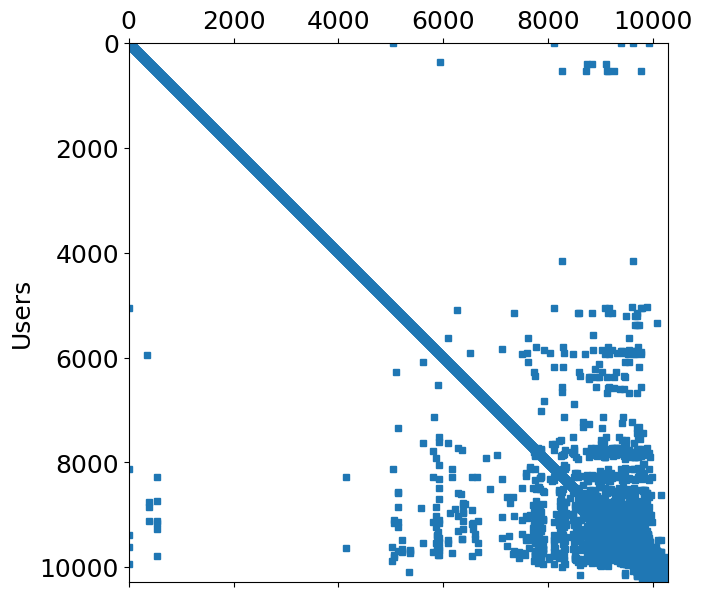

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           10284 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.700000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=1.21e-01 nnz(S)/p=1.24e+01
* iter=1 time=7.33e-02 obj=1.81e+04 |delta(obj)|/obj=4.37e-01 nnz(X,L,W)/p=[1.24e+01 4.56e+01 1.00e+00] lns_iter=3 
* iter=2 time=1.13e-01 obj=1.76e+04 |delta(obj)|/obj=3.03e-02 nnz(X,L,W)/p=[1.24e+01 4.56e+01 8.93e+00] lns_iter=3 
* iter=3 time=7.06e-01 obj=1.72e+04 |delta(obj)|/

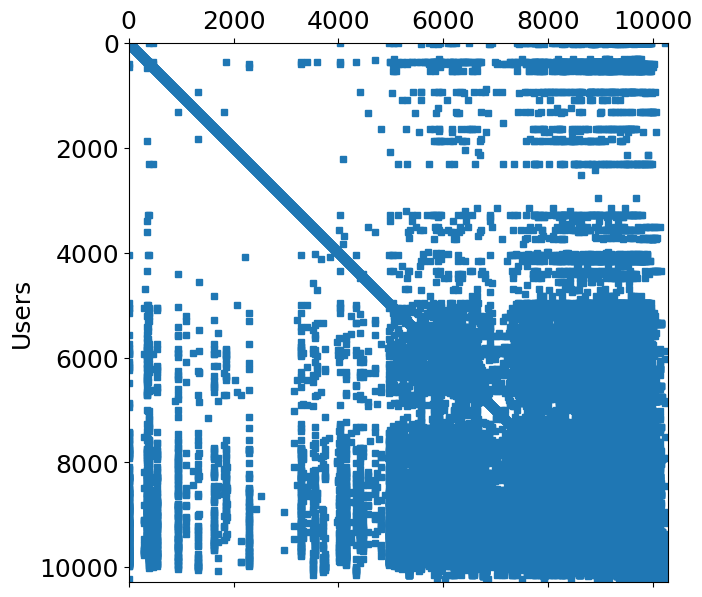

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           10284 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.500000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=1.56e-01 nnz(S)/p=4.54e+01
* iter=1 time=1.95e-01 obj=1.89e+04 |delta(obj)|/obj=4.60e-01 nnz(X,L,W)/p=[4.54e+01 1.06e+02 1.00e+00] lns_iter=4 
* iter=2 time=6.67e-01 obj=1.88e+04 |delta(obj)|/obj=4.23e-03 nnz(X,L,W)/p=[4.54e+01 1.06e+02 1.47e+02] lns_iter=7 
* iter=3 time=3.90e+01 obj=1.77e+04 |delta(obj)|/

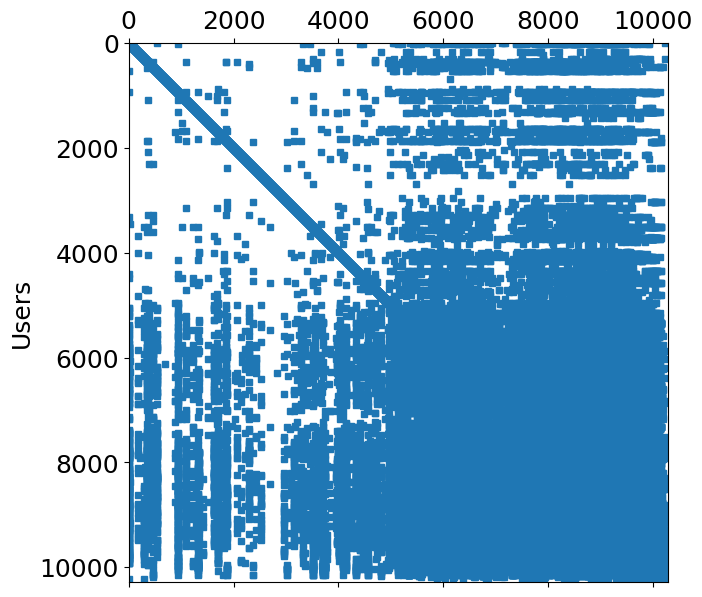

In [23]:
squic_norm_dict = {}

data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    X, _, computation_time = compute_squic(Y_new, rho)
    computation_time = round(computation_time, 2)
    squic_norm_dict[rho] = X
    print(f"time required: {computation_time} seconds")

    nonz, nonz_r = count_nnz(squic_norm_dict[rho], ROWS)

    if is_symmetric(squic_norm_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append('Yes')
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append('No')

    sparsity_pattern(squic_norm_dict[rho])

    data_nnz.append(nonz)
    data_nnzr.append(round(nonz_r, 2))
    data_time.append(computation_time)


table_squic_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]

# SQUIC-Fit

In [24]:
fit_norm_dict = {}

In [25]:
# Y = df.T.to_numpy()  # Convert to (users, days)

# # normalize the Y input data to achieve unit variance
# Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# # normalizes each row so that the std dev of each user's balance over the days becomes 1

# # Y_new has shape (Users × Days).
# # S will have shape (Users × Users).

# # double check if this is correct by 
# S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

In [26]:
# stds = np.std(Y, axis=1)
# safe_stds = np.clip(stds, 1e-8, None)  # don't allow std < 1e-8
# Y_new = np.diag(1 / safe_stds) @ Y

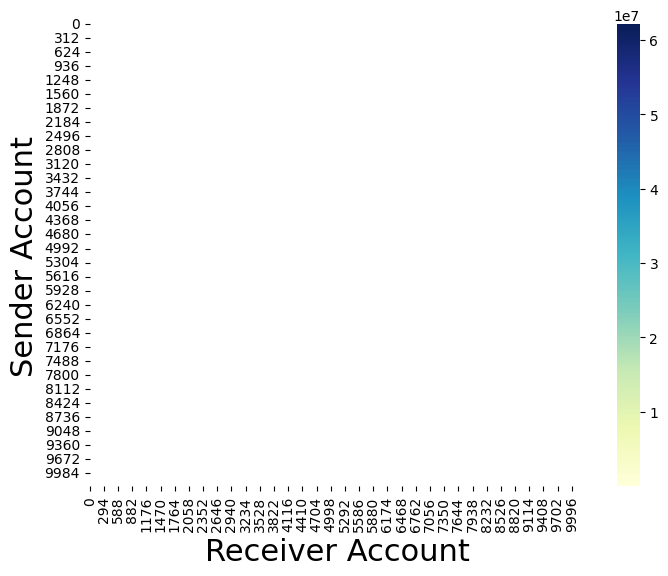

In [27]:
orig = "nameOrig"
dest = "nameDest"
amnt = "amount"  

users_list = []

transactions = pd.read_csv(DATASET)

for _, row in transactions.iterrows():
    if row[orig] not in users_list:
        users_list.append(row[orig])
    if row[dest] not in users_list:
        users_list.append(row[dest])

id_to_int = {user_id: idx for idx, user_id in enumerate(users_list)} 

rows = len(Y)

matrix = np.zeros((rows, rows))

for _, row in transactions.iterrows():
    orig_acct = int(id_to_int[row[orig]])
    bene_acct = int(id_to_int[row[dest]])
    amount = float(row[amnt])

    matrix[orig_acct][bene_acct] += amount

mask = (matrix == 0) # cover all zeros

plt.figure(figsize=(8, 6))
sns.heatmap(matrix, cmap='YlGnBu', fmt=".2f", cbar=True, mask=mask,
            linewidths=0.5, linecolor='white')

plt.xlabel("Receiver Account", fontsize=22)
plt.ylabel("Sender Account", fontsize=22)
plt.show()

Matrix shape: (10284, 10284)
Total elements: 105760656
Zero elements: 104734191
Sparsity: 0.9903 (99.03% zeros)


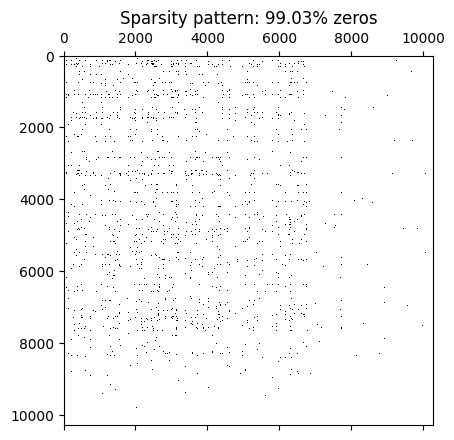

Matrix is sparse (>70.0% zeros). Converting to CSC format.
Memory usage before: 826255.12 KB
Memory usage after: 12069.06 KB


In [28]:
from scipy import sparse

total_elements = matrix.size
zero_elements = np.count_nonzero(matrix == 0)
sparsity = zero_elements / total_elements

print(f"Matrix shape: {matrix.shape}")
print(f"Total elements: {total_elements}")
print(f"Zero elements: {zero_elements}")
print(f"Sparsity: {sparsity:.4f} ({sparsity*100:.2f}% zeros)")

# Visualize the matrix (optional)
plt.spy(matrix)
plt.title(f"Sparsity pattern: {sparsity*100:.2f}% zeros")
plt.show()

sparsity_threshold = 0.7

# Convert to sparse if sparsity is above threshold
if sparsity > sparsity_threshold:
    print(f"Matrix is sparse (>{sparsity_threshold*100}% zeros). Converting to CSC format.")
    sparse_matrix = sparse.csc_matrix(matrix)
    print(f"Memory usage before: {matrix.nbytes / 1024:.2f} KB")
    print(f"Memory usage after: {sum(x.nbytes for x in [sparse_matrix.data, sparse_matrix.indices, sparse_matrix.indptr]) / 1024:.2f} KB")
    matrix = sparse_matrix
else:
    print(f"Matrix is not sparse enough (<{sparsity_threshold*100}% zeros). Keeping as dense.")

In [29]:
l = [0.99, 0.97, 0.95, 0.93, 0.9]


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.996142e+02
 Y:         10284 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.900000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=1.25e+00 time=1.38e-01
* iter=1 time=2.05e-02 obj=1.73e+04 |delta(obj)|/obj=4.10e-01 nnz(X,L,W)/p=[1.25e+00 9.78e-01 1.00e+00] lns_iter=2 
* iter=2 time=2.30e-02 obj=1.73e+04 |delta(obj)|/obj=8.97e-06 nnz(X,L,W)/p=[1.25e+00 9.78e-01 1.10e+00] lns_iter=1 
#SQUIC Finished: time=1.87e-01 nnz(X,

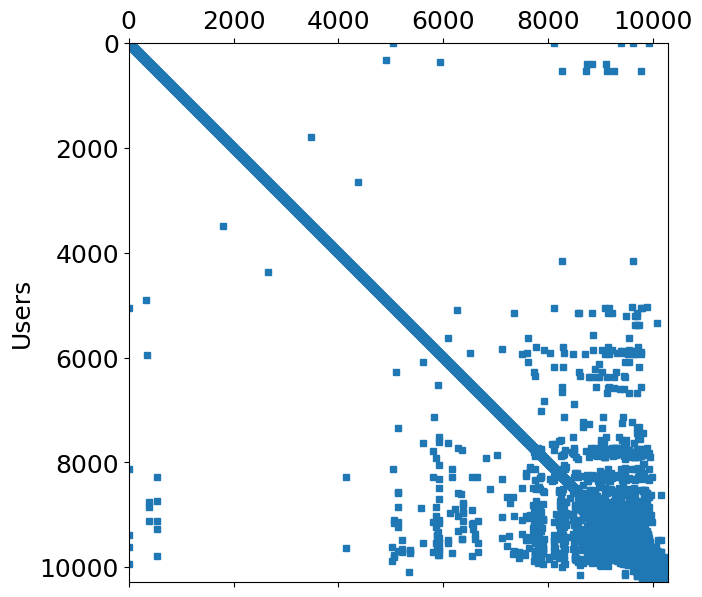


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.996142e+02
 Y:         10284 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.700000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=1.24e+01 time=1.36e-01
* iter=1 time=6.27e-02 obj=1.81e+04 |delta(obj)|/obj=4.37e-01 nnz(X,L,W)/p=[1.24e+01 4.46e+01 1.00e+00] lns_iter=3 
* iter=2 time=1.06e-01 obj=1.76e+04 |delta(obj)|/obj=3.03e-02 nnz(X,L,W)/p=[1.24e+01 4.46e+01 8.92e+00] lns_iter=3 
* iter=3 time=6.79e-01 obj=1.72e+04 |

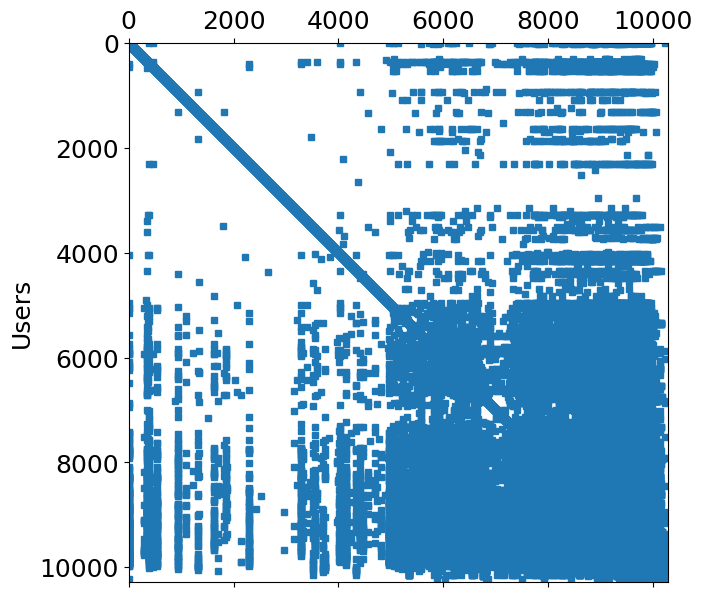


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.996142e+02
 Y:         10284 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.500000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=4.53e+01 time=1.55e-01
* iter=1 time=1.97e-01 obj=1.89e+04 |delta(obj)|/obj=4.60e-01 nnz(X,L,W)/p=[4.53e+01 1.06e+02 1.00e+00] lns_iter=4 
* iter=2 time=6.69e-01 obj=1.88e+04 |delta(obj)|/obj=4.25e-03 nnz(X,L,W)/p=[4.53e+01 1.06e+02 1.38e+02] lns_iter=7 
* iter=3 time=3.70e+01 obj=1.77e+04 |

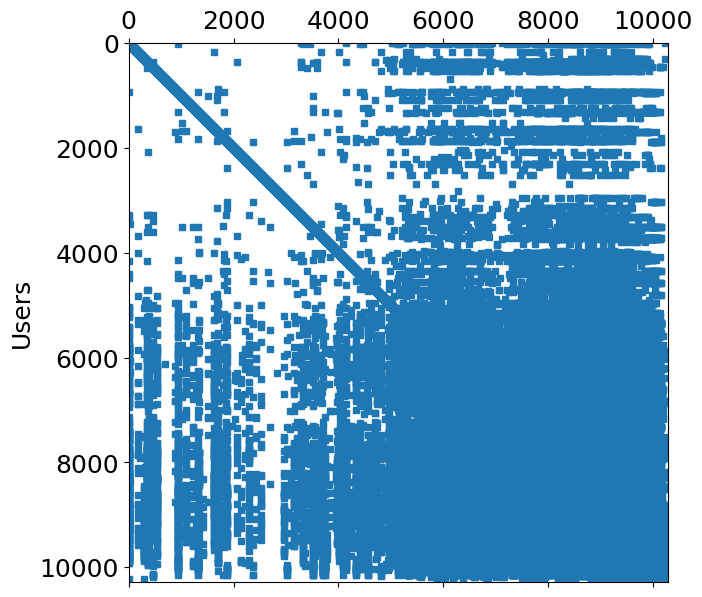


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.996142e+02
 Y:         10284 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.300000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=9.18e+01 time=2.18e-01
* iter=1 time=4.70e-01 obj=1.95e+04 |delta(obj)|/obj=4.76e-01 nnz(X,L,W)/p=[9.18e+01 1.59e+02 1.00e+00] lns_iter=6 
* iter=2 time=1.21e+00 obj=1.93e+04 |delta(obj)|/obj=6.67e-03 nnz(X,L,W)/p=[9.18e+01 1.59e+02 2.16e+01] lns_iter=7 
* iter=3 time=2.36e+01 obj=1.91e+04 |

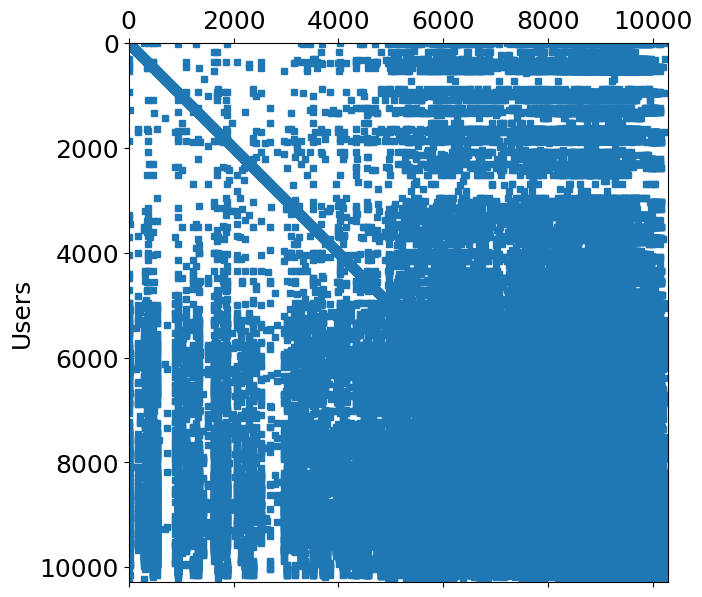


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.996142e+02
 Y:         10284 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=1.71e+02 time=3.55e-01
* iter=1 time=9.96e-01 obj=1.93e+04 |delta(obj)|/obj=4.71e-01 nnz(X,L,W)/p=[1.71e+02 2.46e+02 1.00e+00] lns_iter=7 
* iter=2 time=3.15e+00 obj=1.92e+04 |delta(obj)|/obj=4.18e-03 nnz(X,L,W)/p=[1.71e+02 2.46e+02 1.58e+02] lns_iter=8 


In [ ]:
data_nnz = []
data_nnzr = []
data_time = []
data_sym = []

for rho in l:
    fit_norm_dict[rho], end_time = squic_fit_matrix(Y=Y_new, l=rho, matrix=matrix)
    end_time = round(end_time, 2)
    print(f"required time: {end_time}")
    
    nnz, nnz_r = nnz_fit(fit_norm_dict[rho], ROWS)
    print(f"nnz = {nnz} per rows = {nnz_r}")

    if is_symmetric(fit_norm_dict[rho]):
        print(f"✅ Matrix is symmetric per rho {rho}")
        data_sym.append('Yes')
    else:
        print(f"❌ Matrix is not symmetric per rho {rho}")
        data_sym.append('No')

    sparsity_pattern(fit_norm_dict[rho])

    data_nnz.append(nnz)
    data_nnzr.append(round(nnz_r, 2))
    data_time.append(end_time)

table_fit = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time,
    ["Symmetric"] + data_sym
]

# Table

In [69]:
def table(data, title, l):
    table = tabulate(
        data,
        headers=[title] + l,
        tablefmt="fancy_grid",
        numalign="center",
        stralign="center"
    )
    return table

In [70]:
# print(table(table_squic_norm, "SQUIC NORM", l))

print(table(table_fit, "SQUIC FIT NORM", l))

╒══════════════════╤════════╤════════╤════════╤════════╤═══════╕
│  SQUIC FIT NORM  │  0.99  │  0.97  │  0.95  │  0.93  │  0.9  │
╞══════════════════╪════════╪════════╪════════╪════════╪═══════╡
│       NNZ        │  1048  │  2028  │  4874  │  8062  │ 9856  │
├──────────────────┼────────┼────────┼────────┼────────┼───────┤
│     NNZ/Row      │  1.02  │  1.98  │  4.75  │  7.86  │ 9.61  │
├──────────────────┼────────┼────────┼────────┼────────┼───────┤
│     Time (s)     │  0.21  │  0.18  │  0.19  │  0.28  │  0.5  │
├──────────────────┼────────┼────────┼────────┼────────┼───────┤
│    Symmetric     │  Yes   │  Yes   │  Yes   │  Yes   │  Yes  │
╘══════════════════╧════════╧════════╧════════╧════════╧═══════╛
